# Problema 3

### Clasificare multi-clasa

In [1]:
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LogisticRegression
import math
import warnings; warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt
import os
import numpy as np

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets
y = y['class']

print(y)

inputs = [[x,y,z,k] for x,y,z,k in zip(X['sepal length'],X['sepal width'],X['petal length'],X['petal width'])]

# normalisation function
def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData) # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: class, Length: 150, dtype: object


### Impartirea datelor pe test & train + standardizarea datelor

In [2]:
from sklearn.decomposition import PCA

# making sure that the "random" numbers are always going to be the same ones (in order to get the same results every time)
np.random.seed(5)

# building an index vector & selecting 80% of it for training, and the rest 20% for testing the algorithm
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
testSample = [i for i in indexes  if not i in trainSample]


trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [y[i] for i in trainSample]

testInputs = [inputs[i] for i in testSample]
testOutputs = [y[i] for i in testSample]

trainInputs, testInputs = normalisation(trainInputs, testInputs)


# PCA - Principal Component Analysis -> useful for reducing the number of columns, while still taking into account all features
pca = PCA(n_components=2)
trainInputs = pca.fit_transform(trainInputs)
testInputs = pca.transform(testInputs)

### Train + predictii CU TOOL

In [3]:
clasificator = LogisticRegression()

clasificator.fit(trainInputs, trainOutputs)
w = []

for index in range(len(clasificator.classes_)):
    w0 = clasificator.intercept_[index]
    w1 = clasificator.coef_[index][0]
    w2 = clasificator.coef_[index][1]

    w.append([w0, w1, w2])

    print(f"f{index} = {w0} + {w1} * PC1 + {w2} * PC2 \n")


f0 = -0.20005486401573405 + -2.701527851969785 * PC1 + 0.5529627878018535 * PC2 

f1 = 1.8725289081674636 + -0.16018037229423443 * PC1 + -0.40893465042207416 * PC2 

f2 = -1.6724740441517314 + 2.861708224264018 * PC1 + -0.14402813737977851 * PC2 



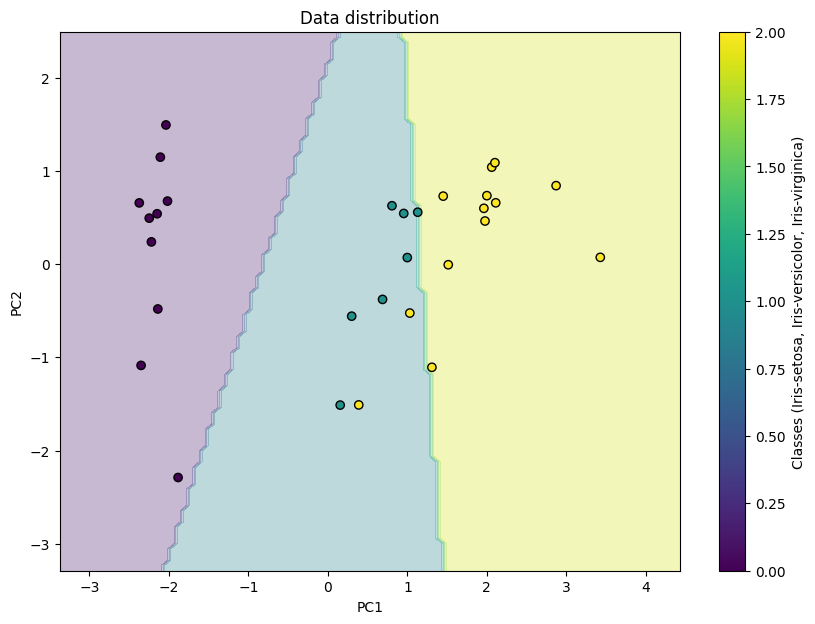

In [4]:
from sklearn.inspection import DecisionBoundaryDisplay

computedOutputs = clasificator.predict(testInputs)


x_coords = [x[0] for x in testInputs] # datele pentru PC1
y_coords = [x[1] for x in testInputs] # datele pentru PC2

plot_colors = [-1] * len(testOutputs)
for index in range(len(testOutputs)):
    if testOutputs[index] == 'Iris-setosa':
        plot_colors[index] = 0
    elif testOutputs[index] == 'Iris-virginica':
        plot_colors[index] = 2
    else:
        plot_colors[index] = 1


plt.figure(figsize=(10, 7))

# used for coloring the background
# this represents how the algorithm parts the data
disp = DecisionBoundaryDisplay.from_estimator(
    clasificator,
    testInputs,
    response_method="predict",
    cmap='viridis',
    alpha=0.3,
    ax=plt.gca() # Folosește axele curente
)

# real outputs
plt.scatter(testInputs[:, 0], testInputs[:, 1], c=plot_colors, edgecolors='k', cmap='viridis')

plt.title("Data distribution")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Classes (Iris-setosa, Iris-versicolor, Iris-virginica)')
plt.show()

### Train + predictii COD PROPRIU

In [5]:
from MyLogisticMultiRegression import MyLogisticMultiRegression

clasificatorP = MyLogisticMultiRegression()

clasificatorP.fit(trainInputs, trainOutputs)
wp = []

for index in range(len(clasificatorP.classes_)):
    w0 = clasificatorP.intercept_[index]
    w1 = clasificatorP.coef_[index][0]
    w2 = clasificatorP.coef_[index][1]

    wp.append([w0, w1, w2])

    print(f"f{index} = {w0} + {w1} * PC1 + {w2} * PC2 \n")


f0 = 0.670415011267171 + -0.4773875567467951 * PC1 + 0.6153512483706475 * PC2 

f1 = 1.0291608736720639 + 0.6653745285724771 * PC1 + 0.07968776569101335 * PC2 

f2 = 0.6243051117802269 + 1.2619126500753424 * PC1 + 0.4856059432402421 * PC2 



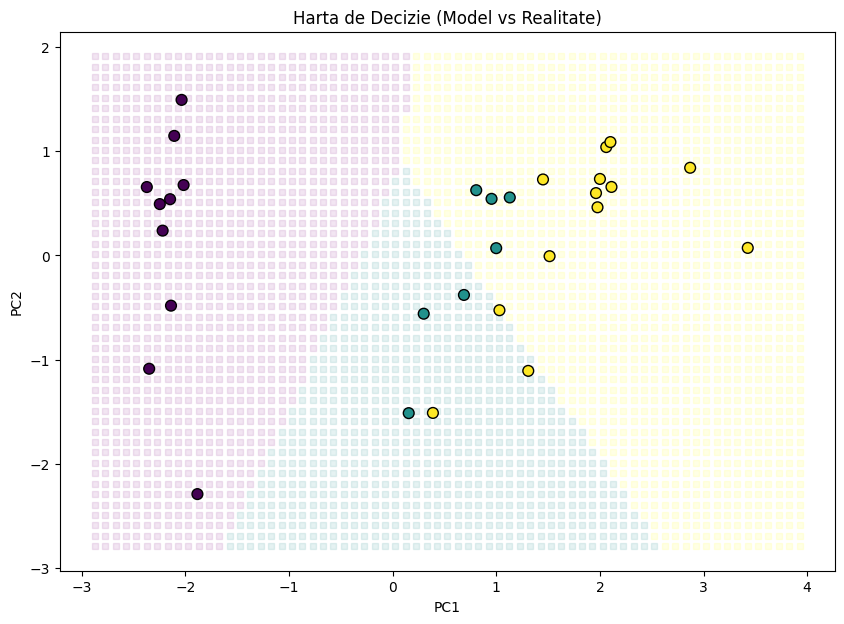

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# marginile graficului
x_min = min([x[0] for x in testInputs]) - 0.5
x_max = max([x[0] for x in testInputs]) + 0.5
y_min = min([x[1] for x in testInputs]) - 0.5
y_max = max([x[1] for x in testInputs]) + 0.5


pas = 0.1
plt.figure(figsize=(10, 7))

# colorarea fundalului
for x in np.arange(x_min, x_max, pas):
    for y in np.arange(y_min, y_max, pas):
        # prezicerea pentru punctul (x,y)
        prezicere = clasificatorP.predict([[x, y]])[0]

        if prezicere == 'Iris-setosa':
            culoare_fundal = 'purple'
        elif prezicere == 'Iris-virginica':
            culoare_fundal = 'yellow'
        else:
            culoare_fundal = 'teal'

        # pentru a construi efectiv fundalul (patratica cu patratica)
        plt.plot(x, y, marker='s', markersize=5, color=culoare_fundal, alpha=0.1)

# se adauga punctele reale
plt.scatter(testInputs[:, 0], testInputs[:, 1], c=plot_colors, edgecolors='k', cmap='viridis', s=60, zorder=3)

plt.title("Harta de Decizie (Model vs Realitate)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
# predictie rezultat

floare_noua = [[5.35, 3.85, 1.25, 0.4]]
floare_noua = pca.transform(floare_noua)
rez = clasificator.predict(floare_noua)
print("Modelul antrenat cu tool spune ca floarea este: " + rez[0])

rez = clasificatorP.predict(floare_noua)
print("Modelul antrenat utilizand cod propriu spune ca floarea este: " + rez[0])

Modelul antrenat cu tool spune ca floarea este: Iris-virginica
Modelul antrenat utilizand cod propriu spune ca floarea este: Iris-virginica


### Performanta CU TOOL

In [9]:
computedOutputs = clasificator.predict(testInputs)
computedOutputsP = clasificatorP.predict(testInputs)

def matrice_de_confuzie(outputs,computed,positive):
    TP = 0.0
    FP = 0.0
    TN = 0.0
    FN = 0.0

    for index in range(len(outputs)):
        if outputs[index] == computed[index] == positive:
            TP += 1
        elif outputs[index] != computed[index] and computed[index] == positive:
            FP += 1
        elif outputs[index] == computed[index] and computed[index] != positive:
            TN += 1
        else:
            FN += 1

    precision = TP / (TP + FP)
    recall = TP / (TP + FN)

    return precision, recall

def acuratete(outputs,computed):
    accuracy = 0.0
    for index in range(len(outputs)):
        if outputs[index] == computed[index]:
            accuracy += 1

    return accuracy / len(outputs)


precision1,recall1 = matrice_de_confuzie(testOutputs,computedOutputs,'Iris-setosa')
precision2,recall2 = matrice_de_confuzie(testOutputs,computedOutputs,'Iris-virginica')
precision3,recall3 = matrice_de_confuzie(testOutputs,computedOutputs,'Iris-versicolor')

macro_precision = (precision1 + precision2 + precision3)/3
macro_recall = (recall1 + recall2 + recall3)/3
accuracy = acuratete(testOutputs,computedOutputs)

print("Accuracy: ", accuracy)
print("Precision: ", macro_precision)
print("Recall: " , macro_recall)


Accuracy:  0.9
Precision:  0.8888888888888888
Recall:  0.8241758241758242


### Performanta COD PROPRIU

In [10]:
precision1,recall1 = matrice_de_confuzie(testOutputs,computedOutputsP,'Iris-setosa')
precision2,recall2 = matrice_de_confuzie(testOutputs,computedOutputsP,'Iris-virginica')
precision3,recall3 = matrice_de_confuzie(testOutputs,computedOutputsP,'Iris-versicolor')

macro_precision = (precision1 + precision2 + precision3)/3
macro_recall = (recall1 + recall2 + recall3)/3
accuracy = acuratete(testOutputs,computedOutputsP)

print("Accuracy: ", accuracy)
print("Precision: ", macro_precision)
print("Recall: " , macro_recall)

Accuracy:  0.7666666666666667
Precision:  0.7380952380952381
Recall:  0.5953458306399483
